In [7]:
# Initializations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/data_processed.csv")
df.head()

,game_id,subframe_max,subframe_count,cleared_sum,garbage_cleared_sum,attack_sum,t_spin_<lambda>,btb_mean,btb_max,combo_mean,...,incoming_garbage_max,won_first,rating_first,glicko_first,glicko_rd_first,duration_sec,pps,attack_per_piece,attack_per_sec,tspin_rate
0,1,42360,196,115,0,161,15,1.933673,8,0.520408,...,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,2.280453,0.076531
1,2,42786,215,133,0,126,12,0.413953,4,0.590698,...,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,1.766933,0.055814
2,3,29565,152,85,0,102,10,0.611842,3,0.605263,...,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,2.070015,0.065789
3,4,29570,136,83,0,85,5,0.786765,4,0.588235,...,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,1.724721,0.036765
4,5,41715,191,107,0,128,11,1.277487,7,0.539267,...,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,1.841064,0.057592


In [8]:
# Data Overview and Quality
df.info()
df.describe(include="all")
print("Missing values per column:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 76692 entries, 0 to 76691
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 76692 non-null  int64  
 1   subframe_max            76692 non-null  int64  
 2   subframe_count          76692 non-null  int64  
 3   cleared_sum             76692 non-null  int64  
 4   garbage_cleared_sum     76692 non-null  int64  
 5   attack_sum              76692 non-null  int64  
 6   t_spin_<lambda>         76692 non-null  int64  
 7   btb_mean                76692 non-null  float64
 8   btb_max                 76692 non-null  int64  
 9   combo_mean              76692 non-null  float64
 10  combo_max               76692 non-null  int64  
 11  immediate_garbage_mean  76692 non-null  float64
 12  immediate_garbage_max   76692 non-null  int64  
 13  incoming_garbage_mean   76692 non-null  float64
 14  incoming_garbage_max    76692 non-null  int64  
 

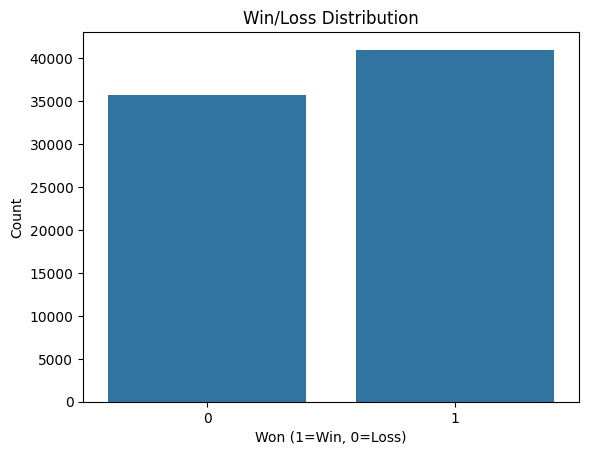

won_first
1    0.534684
0    0.465316
Name: proportion, dtype: float64

In [9]:
# Distribution
sns.countplot(x="won_first", data=df)
plt.title("Win/Loss Distribution")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Count")
plt.show()

df["won_first"].value_counts(normalize=True)

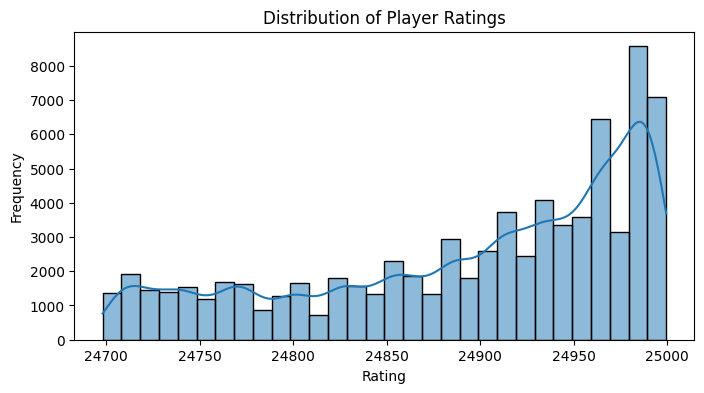

In [10]:
# Distribution of player ratings
plt.figure(figsize=(8, 4))
sns.histplot(df["rating_first"], kde=True, bins=30)
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

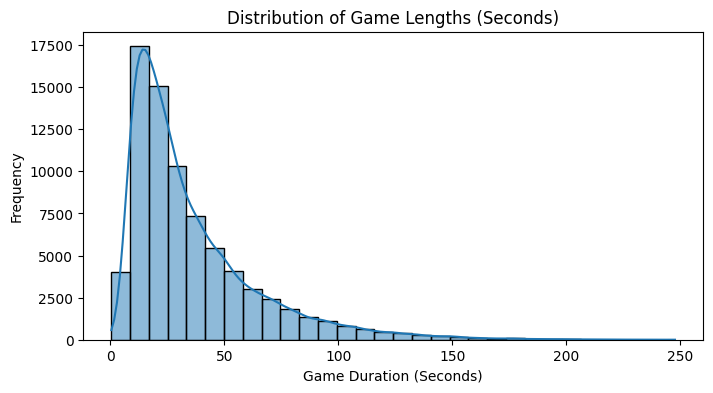

In [11]:
# Distribution of game lengths in seconds
plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"], kde=True, bins=30)
plt.title("Distribution of Game Lengths (Seconds)")
plt.xlabel("Game Duration (Seconds)")
plt.ylabel("Frequency")
plt.show()

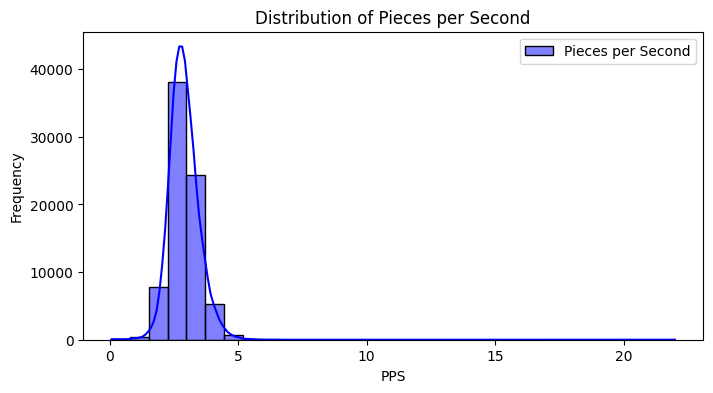

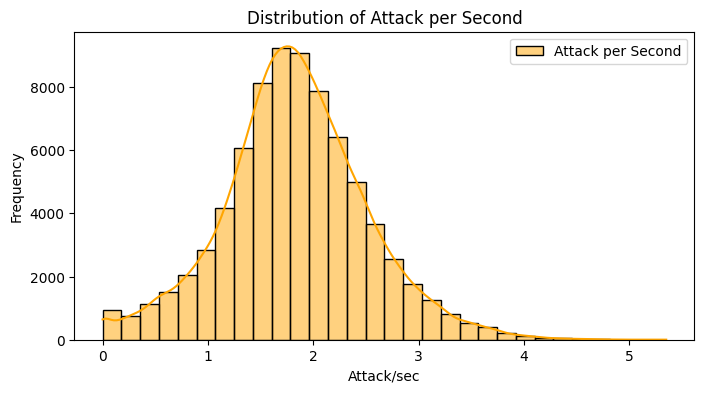

In [12]:
# Distribution of pieces per second (pps) and attack per second
plt.figure(figsize=(8, 4))
sns.histplot(df["pps"], kde=True, color="blue", bins=30, label="Pieces per Second")
plt.title("Distribution of Pieces per Second")
plt.xlabel("PPS")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["attack_per_sec"], kde=True, color="orange", bins=30, label="Attack per Second"
)
plt.title("Distribution of Attack per Second")
plt.xlabel("Attack/sec")
plt.ylabel("Frequency")
plt.legend()
plt.show()

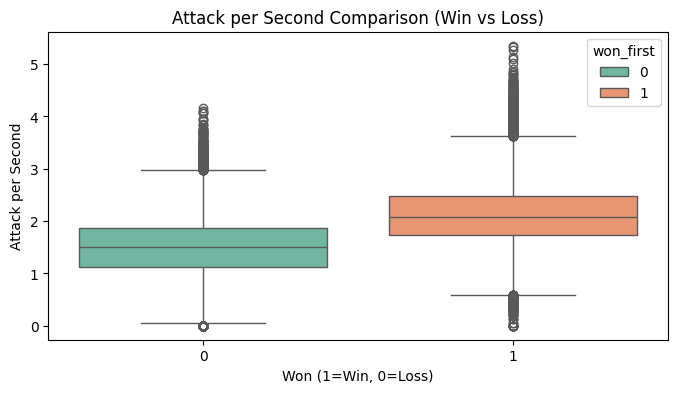

In [14]:
# Average attack per minute: Compare between winning and losing games
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="won_first",
    y="attack_per_sec",
    data=df,
    hue="won_first",
    palette="Set2",
    dodge=False,
)
plt.title("Attack per Second Comparison (Win vs Loss)")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Attack per Second")
plt.show()